# Options pricing three ways — a cross-validation demo

This library prices vanilla equity options with three independently built engines — the
**Black-Scholes-Merton closed form**, a **Cox-Ross-Rubinstein binomial tree**, and
**Monte Carlo simulation** — and this notebook demonstrates that they agree, how fast
each numerical method converges, and what the Greeks and the implied-vol surface look
like.

Why this framing: any one of these pricers is textbook material. The signal is in the
*validation* — three independent implementations agreeing to tolerance, convergence
rates matching theory (O(1/N) for the tree, O(N^-1/2) for Monte Carlo), and a
model-free identity (put-call parity) holding to machine precision. That is how pricing
code earns trust in practice, and the same checks live permanently in `tests/`
(174 tests, all passing).

In [1]:
%matplotlib inline
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optionslib import ExerciseStyle, Option, OptionType
from optionslib import binomial, black_scholes, monte_carlo
from optionslib.vol_surface import iv_surface

ASSETS = Path("..") / "assets"
ASSETS.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

## 1. One option, three engines

A 1-year call, spot 100, strike 105, 25% vol, 5% rate, 2% dividend yield. The closed
form is exact within the model, so it serves as the reference; the tree and the
simulation should land on it up to their known discretisation/sampling error. The Monte
Carlo estimate comes with a standard error — a simulation price without one is
meaningless, since it is a random variable.

In [2]:
opt = Option(spot=100.0, strike=105.0, maturity=1.0, rate=0.05,
             volatility=0.25, dividend_yield=0.02, option_type=OptionType.CALL)

bs_price = black_scholes.price(opt)
tree_price = binomial.price(opt, steps=2000)
mc = monte_carlo.price(opt, n_paths=500_000, seed=42)

pd.DataFrame({
    "price": [bs_price, tree_price, mc.price],
    "abs error vs closed form": [0.0, abs(tree_price - bs_price), abs(mc.price - bs_price)],
    "std error": [float("nan"), float("nan"), mc.std_error],
}, index=["Black-Scholes (closed form)", "Binomial tree (N=2000)",
          "Monte Carlo (500k paths, antithetic)"]).round(6)

,price,abs error vs closed form,std error
Black-Scholes (closed form),8.941176,0.000000,NaN
Binomial tree (N=2000),8.942156,0.000981,NaN
"Monte Carlo (500k paths, antithetic)",8.948582,0.007406,0.018869


## 2. Convergence — does the error die the way theory says it should?

- **Binomial tree**: error is O(1/N), with the classic odd/even sawtooth around the
  strike. The dashed guide is `2.42/N` — the constant measured for this option — and
  the error rides it for three decades.
- **Monte Carlo**: the standard error falls as N^-1/2 (halving the error costs 4x the
  paths), antithetic variates cut it by a constant factor at equal path count, and the
  realised error stays inside a few standard errors of zero, as it must.

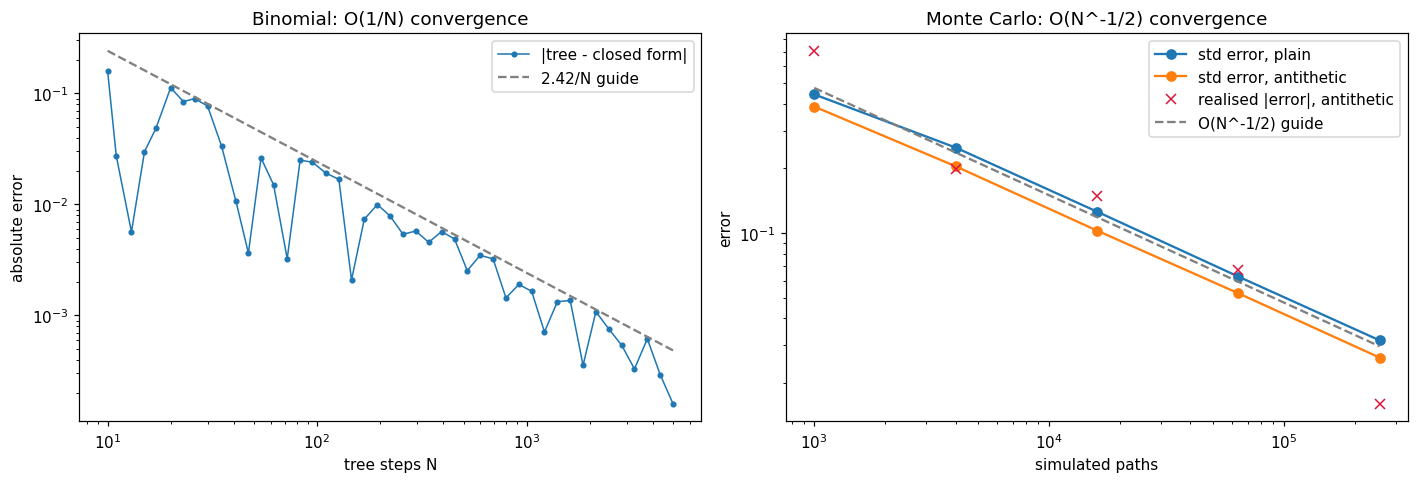

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

steps_grid = np.unique(np.geomspace(10, 5000, 45).astype(int))
tree_err = [abs(binomial.price(opt, steps=int(n)) - bs_price) for n in steps_grid]
ax1.loglog(steps_grid, tree_err, marker=".", lw=1, label="|tree - closed form|")
ax1.loglog(steps_grid, 2.42 / steps_grid, "--", color="gray", label="2.42/N guide")
ax1.set_xlabel("tree steps N")
ax1.set_ylabel("absolute error")
ax1.set_title("Binomial: O(1/N) convergence")
ax1.legend()

paths_grid = np.array([1_000, 4_000, 16_000, 64_000, 256_000])
plain = [monte_carlo.price(opt, n_paths=int(n), antithetic=False, seed=7) for n in paths_grid]
anti = [monte_carlo.price(opt, n_paths=int(n), antithetic=True, seed=7) for n in paths_grid]
ax2.loglog(paths_grid, [r.std_error for r in plain], marker="o", label="std error, plain")
ax2.loglog(paths_grid, [r.std_error for r in anti], marker="o", label="std error, antithetic")
ax2.loglog(paths_grid, [abs(r.price - bs_price) for r in anti], "x", ls="none",
           color="crimson", label="realised |error|, antithetic")
ax2.loglog(paths_grid, 15.0 / np.sqrt(paths_grid), "--", color="gray", label="O(N^-1/2) guide")
ax2.set_xlabel("simulated paths")
ax2.set_ylabel("error")
ax2.set_title("Monte Carlo: O(N^-1/2) convergence")
ax2.legend()

fig.tight_layout()
fig.savefig(ASSETS / "convergence.png", bbox_inches="tight")
plt.show()

## 3. The Greeks across spot

Full analytic risk sensitivities from the closed form. Solid lines are the call,
dashed the put; gamma and vega are identical for both (the dashed line sits exactly on
the solid one) — they are second-order/vol sensitivities of the same terminal
distribution, and only the payoff direction differs between call and put.

Reading them left to right: delta is the hedge ratio (note the call/put deltas differ
by exactly the dividend-discounted forward, another parity fact); gamma and vega
concentrate at the money, which is where hedging is hardest and vol matters most;
theta shows time decay is steepest at the money; rho flips sign between calls
and puts because rates raise the forward and discount the strike.

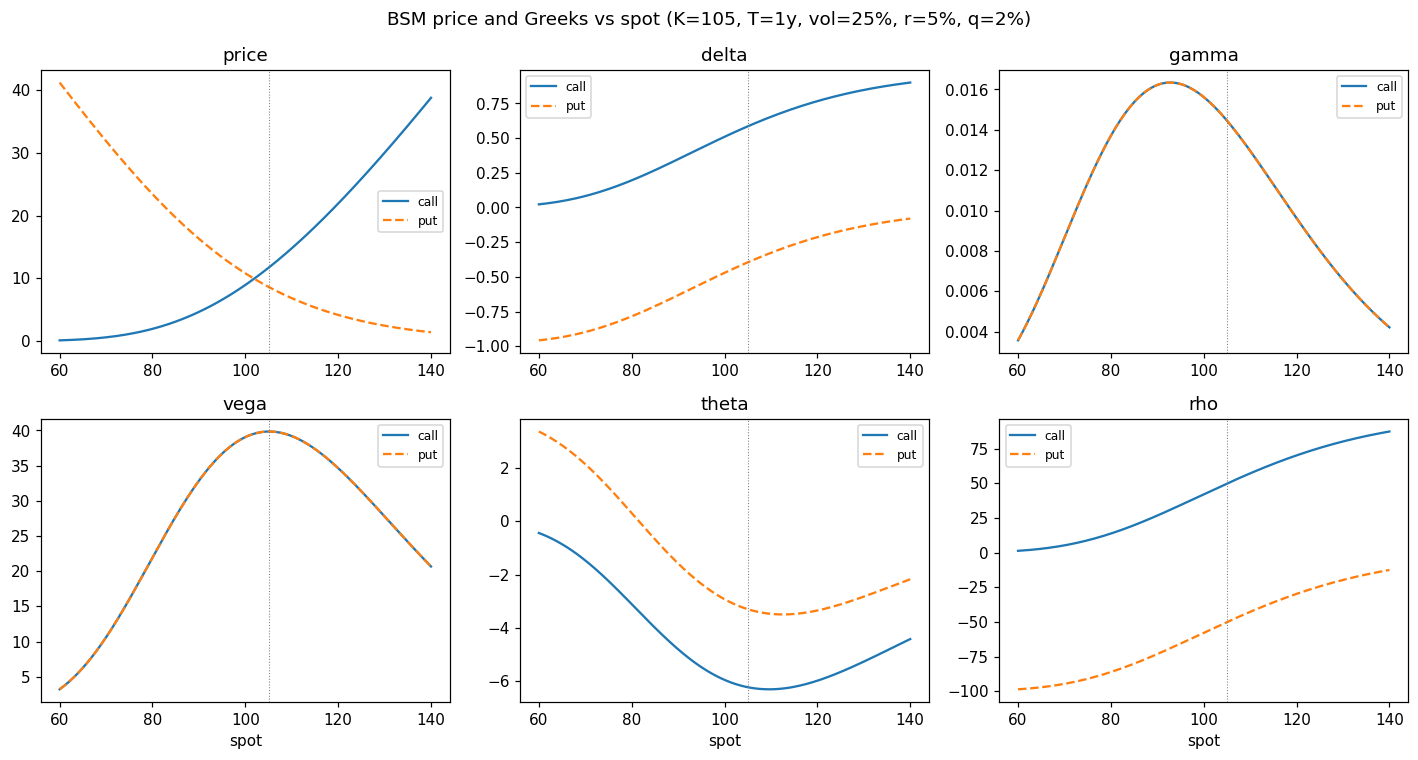

In [4]:
spots = np.linspace(60, 140, 161)
panels = [("price", black_scholes.price), ("delta", black_scholes.delta),
          ("gamma", black_scholes.gamma), ("vega", black_scholes.vega),
          ("theta", black_scholes.theta), ("rho", black_scholes.rho)]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, fn) in zip(axes.flat, panels):
    for option_type, style in [(OptionType.CALL, "-"), (OptionType.PUT, "--")]:
        values = [fn(replace(opt, spot=float(s), option_type=option_type)) for s in spots]
        ax.plot(spots, values, style, label=option_type.value)
    ax.axvline(opt.strike, color="gray", lw=0.7, ls=":")
    ax.set_title(name)
    ax.legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("spot")
fig.suptitle("BSM price and Greeks vs spot (K=105, T=1y, vol=25%, r=5%, q=2%)")
fig.tight_layout()
fig.savefig(ASSETS / "greeks.png", bbox_inches="tight")
plt.show()

## 4. Put-call parity — a model-free check

`C - P = S e^(-qT) - K e^(-rT)` holds by static replication, independent of any model
assumptions — so it must hold to machine precision, not to a tolerance. A pricing
library that misses parity by more than float noise has a bug, full stop.

In [5]:
strikes = np.linspace(70, 140, 15)
maturities = [0.1, 0.5, 1.0, 2.0]

worst = 0.0
for T in maturities:
    for K in strikes:
        call = replace(opt, strike=float(K), maturity=T, option_type=OptionType.CALL)
        put = replace(opt, strike=float(K), maturity=T, option_type=OptionType.PUT)
        lhs = black_scholes.price(call) - black_scholes.price(put)
        rhs = opt.spot * np.exp(-opt.dividend_yield * T) - K * np.exp(-opt.rate * T)
        worst = max(worst, abs(lhs - rhs))

print(f"max |C - P - (S e^-qT - K e^-rT)| over {len(maturities) * len(strikes)} "
      f"contracts: {worst:.2e}")
assert worst < 1e-12

max |C - P - (S e^-qT - K e^-rT)| over 60 contracts: 1.95e-14


## 5. American exercise — what is exercising early actually worth?

The tree prices American options by comparing continuation value against immediate
exercise at every node, so the **early-exercise premium** falls straight out:
American price minus European price, computed on the same tree so discretisation
error cancels.

Two classic results are visible below. The American call on a non-dividend payer
carries no premium at all — early exercise throws away time value and collects
nothing, so the line sits at zero (Merton, 1973). The American put is different:
deep in the money, the interest earned on the strike outweighs the remaining
optionality, so exercising now beats waiting — the premium grows with moneyness
until the whole option pins to intrinsic value.

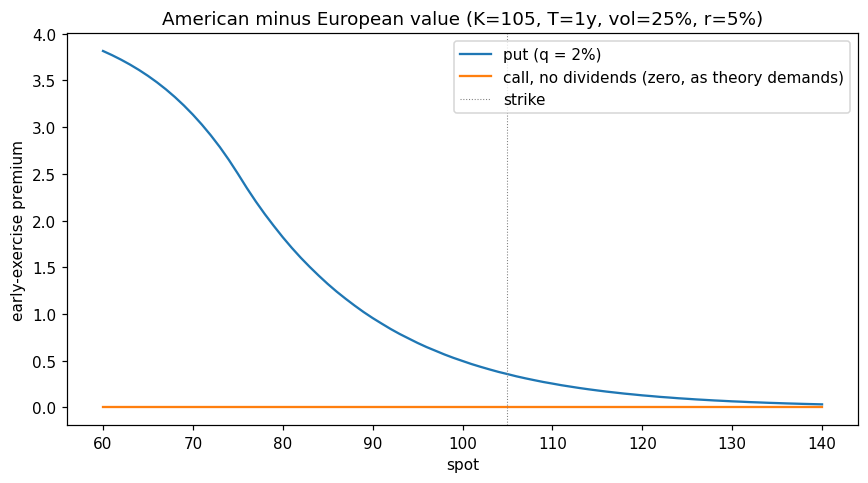

In [6]:
spots_scan = np.linspace(60, 140, 81)

def premium(option_type, dividend_yield):
    prem = []
    for s in spots_scan:
        european = replace(opt, spot=float(s), option_type=option_type,
                           dividend_yield=dividend_yield)
        american = replace(european, style=ExerciseStyle.AMERICAN)
        prem.append(binomial.price(american, steps=1000)
                    - binomial.price(european, steps=1000))
    return np.array(prem)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(spots_scan, premium(OptionType.PUT, 0.02), label="put (q = 2%)")
ax.plot(spots_scan, premium(OptionType.CALL, 0.0),
        label="call, no dividends (zero, as theory demands)")
ax.axvline(opt.strike, color="gray", lw=0.7, ls=":", label="strike")
ax.set_xlabel("spot")
ax.set_ylabel("early-exercise premium")
ax.set_title("American minus European value (K=105, T=1y, vol=25%, r=5%)")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "american_premium.png", bbox_inches="tight")
plt.show()

## 6. Implied-vol smile and surface

The inverse problem: given market prices, back out the vol each one implies. Here the
"market" is synthetic — quotes generated from a known smile (quadratic in
log-moneyness, lifted at the short end) — so recovery can be checked exactly: the dots
(vols recovered from prices alone) should sit on the lines (the true smile).

One honest caveat, encoded in the test suite too: inversion accuracy is limited by
vega. Deep ITM/OTM short-dated options have almost no time value, so a price pins down
their vol only loosely — and in the extreme the time value underflows double precision
entirely, where the solver refuses rather than returning a junk number.

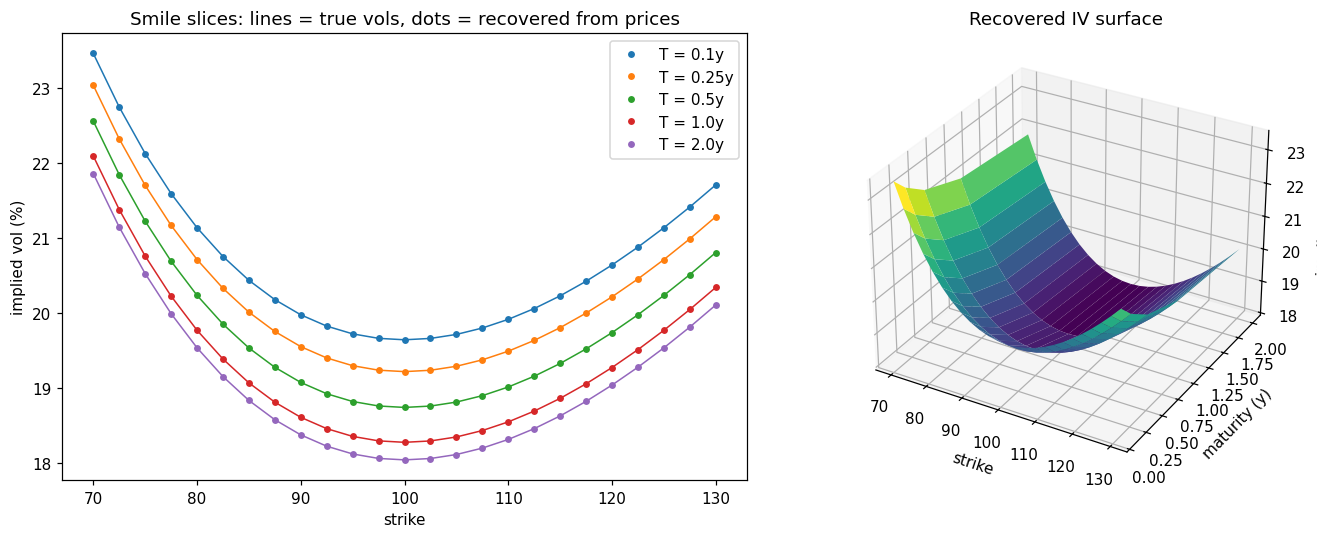

max |recovered - true| vol across the grid: 5.21e-11


In [7]:
spot, rate, q = 100.0, 0.05, 0.01
strikes = np.linspace(70, 130, 25)
maturities = np.array([0.1, 0.25, 0.5, 1.0, 2.0])

log_m = np.log(strikes / spot)
true_vols = 0.18 + 0.3 * log_m[None, :] ** 2 + 0.02 * np.exp(-2.0 * maturities[:, None])

quotes = np.array([
    [black_scholes.price(Option(spot=spot, strike=float(k), maturity=float(t),
                                rate=rate, volatility=float(v), dividend_yield=q))
     for k, v in zip(strikes, true_vols[i])]
    for i, t in enumerate(maturities)
])

recovered = iv_surface(spot, strikes, maturities, quotes, rate, dividend_yield=q)

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1)
for i, t in enumerate(maturities):
    (line,) = ax1.plot(strikes, 100 * true_vols[i], lw=1)
    ax1.plot(strikes, 100 * recovered[i], "o", ms=3.5, color=line.get_color(),
             label=f"T = {t}y")
ax1.set_xlabel("strike")
ax1.set_ylabel("implied vol (%)")
ax1.set_title("Smile slices: lines = true vols, dots = recovered from prices")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
K, T = np.meshgrid(strikes, maturities)
ax2.plot_surface(K, T, 100 * recovered, cmap="viridis")
ax2.set_xlabel("strike")
ax2.set_ylabel("maturity (y)")
ax2.set_zlabel("implied vol (%)")
ax2.set_title("Recovered IV surface")

fig.tight_layout()
fig.savefig(ASSETS / "surface.png", bbox_inches="tight")
plt.show()

print(f"max |recovered - true| vol across the grid: "
      f"{np.nanmax(np.abs(recovered - true_vols)):.2e}")

## Takeaways

- Three independent engines agree on European prices to their theoretical error
  bounds; the binomial tree adds American exercise on top.
- Convergence rates match theory: O(1/N) for the tree, O(N^-1/2) for Monte Carlo,
  with antithetic variates buying a constant-factor improvement.
- Put-call parity — model-free — holds to ~1e-14.
- The early-exercise premium behaves exactly as theory demands: zero for the
  no-dividend call, growing with moneyness for the put until it pins to intrinsic.
- The IV surface round-trips exactly where the problem is well-conditioned, and the
  solver is explicit about where it is not.

Limitations and next steps are in the README: constant-vol GBM world, no discrete
dividends, no term structures, and Longstaff-Schwartz would be the natural
cross-check for American exercise.